## Importing Packages and Data

In [1]:
import os
import warnings
import glob
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import bbknn
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mtick
import seaborn as sb
from matplotlib import rcParams, colors
from anndata import AnnData
from scipy import stats

from plot_utils import *

mpl.rcParams['pdf.fonttype'] = 42
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, frameon=False)
warnings.filterwarnings('ignore')

/home/yerrar/.conda/envs/lifestyle_env_v2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
allpbmcs = sc.read('/projects/USERS/athib/Lifestyle/DeidentifiedObjects/Lifestyle_scRNA.h5ad')
allpbmcs

AnnData object with n_obs × n_vars = 119341 × 31720
    obs: 'SampleID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'Annotation', 'Lineage Annotation', 'Group', 'Sex', 'Age', 'Ancestry', 'Body Mass Index (BMI)', 'Total Mass (kg)', 'Lean Mass (kg)', 'Fat Mass (kg)', 'VO2 (mL/kg/min)', 'PPT', 'HBA1C (%)', 'HOMA-IR', 'MATSUDA index', 'RKE60', 'Triglyceride (mg/dL)', 'C-reactive protein', 'ROS byproduct - Isoprostane (pg/mL)', 'Batch'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'Annotatation_colors', 'Annotation_colors', 'Batch_colors', 'Final_GroupAnnotation_colors', 'Final_annotation_v2_colors', 'Final_annotation_v2_revised_colors', 'GroupAnnotation_colors', 'Lineage Annotation_colors', 'OldAnnotations_colors', 'SampleID_colors', 'dendrogram_leiden', 'hvg',

## Figure 5a

In [3]:
B = allpbmcs[allpbmcs.obs['Annotation'].isin([
    'Naive B', 'TrB', 'Memory B', 'Plasmablast', 'ABCs'
])].copy()
B

AnnData object with n_obs × n_vars = 7302 × 31720
    obs: 'SampleID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'Annotation', 'Lineage Annotation', 'Group', 'Sex', 'Age', 'Ancestry', 'Body Mass Index (BMI)', 'Total Mass (kg)', 'Lean Mass (kg)', 'Fat Mass (kg)', 'VO2 (mL/kg/min)', 'PPT', 'HBA1C (%)', 'HOMA-IR', 'MATSUDA index', 'RKE60', 'Triglyceride (mg/dL)', 'C-reactive protein', 'ROS byproduct - Isoprostane (pg/mL)', 'Batch'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'Annotatation_colors', 'Batch_colors', 'Final_GroupAnnotation_colors', 'Final_annotation_v2_colors', 'Final_annotation_v2_revised_colors', 'GroupAnnotation_colors', 'Lineage Annotation_colors', 'OldAnnotations_colors', 'SampleID_colors', 'dendrogram_leiden', 'hvg', 'leiden', 'leiden_colo

In [4]:
sc.pp.neighbors(B, n_pcs=35)
sc.tl.umap(B)

computing neighbors
    using 'X_pca' with n_pcs = 35
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:10)


In [5]:
Bpalette = {
    'Naive B':      '#88CCEE',
    'TrB':          '#44AA99',
    'Memory B':     '#999933',
    'Plasmablast':  '#332288',
    'ABCs':         '#CC6677',
}

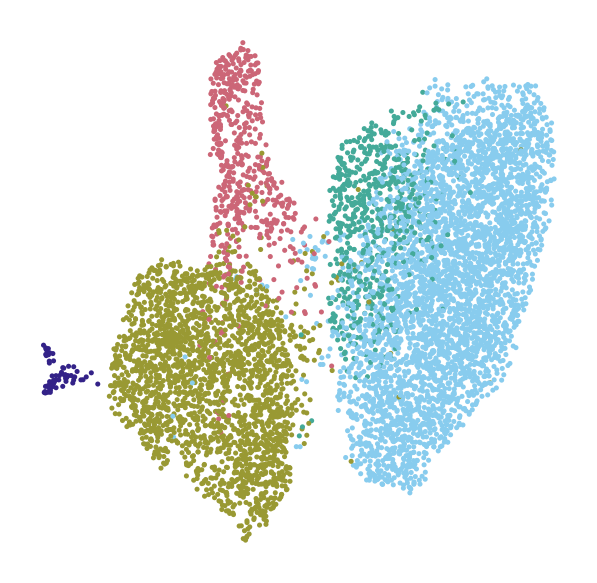

In [6]:
sc.set_figure_params(dpi=90)
sc.pl.umap(B, color=['Annotation'], frameon=False, legend_fontsize=14,
           title='', palette=Bpalette, legend_loc='')

## Figure 5b

In [7]:
degenes_NaiveB = pd.read_csv('/projects/USERS/yerrar/Lifestyle2024/scLifestyle_PREvPOST/Final_Files/DEG_Results/Annotation/DE_Naive_B.csv')
degenes_NaiveB = degenes_NaiveB.rename(columns={'Unnamed: 0': 'gene'}).set_index('gene')

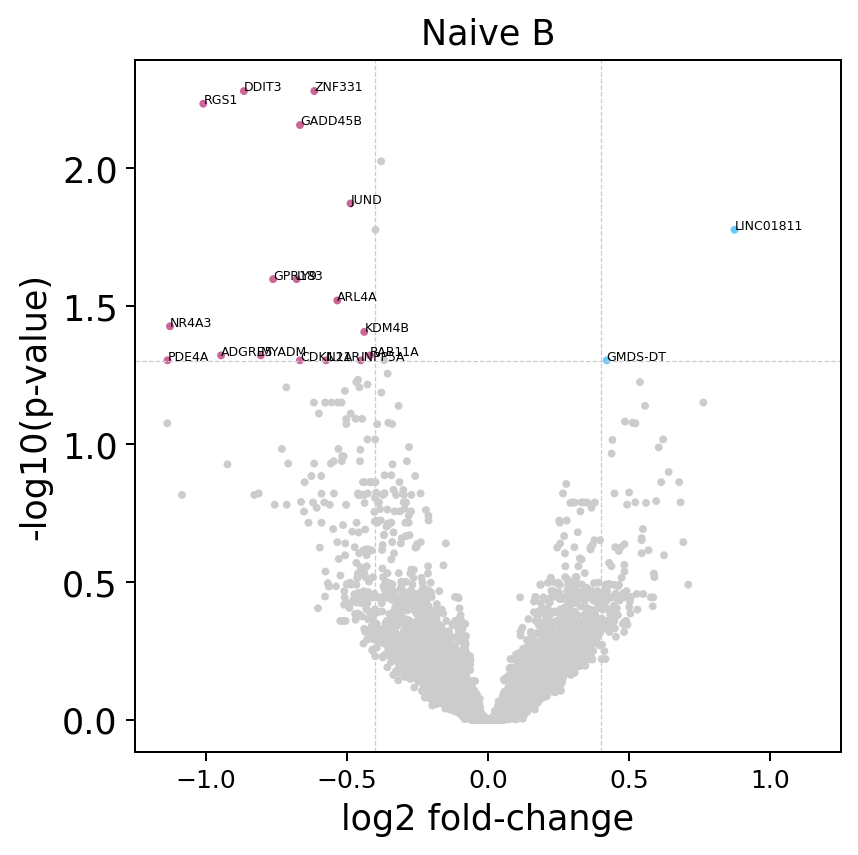

In [8]:
sc.set_figure_params(dpi=90)
fig = plot_volcano(
    degenes_NaiveB,
    title='Naive B',
    logfc=0.4,
    adjustp=0.05,
    label_fc=0.4,
    label_p=0.05,
)
plt.show()

## Figure 5c

In [ ]:
%%R
library(GSEABase)
library(fgsea)
library(msigdb)
library(ggplot2)

msigdb.hs <- getMsigdb(org = "hs", id = "SYM", version = "7.4")
msigdb.hs <- appendKEGG(msigdb.hs)

t_ctype <- lapply(msigdb.hs, GSEABase::collectionType)
t_gsc <- msigdb.hs[
  sapply(t_ctype, GSEABase::bcCategory) %in% "h" |
    sapply(t_ctype, GSEABase::bcSubCategory) %in% c("CP:KEGG", "CP:PID")
]
msigdb_ids <- geneIds(t_gsc)
all_msigdb <- geneIds(msigdb.hs)

exhaust_sets <- c(
  "GSE9650_EXHAUSTED_VS_MEMORY_CD8_TCELL_UP",
  "GSE9650_EXHAUSTED_VS_MEMORY_CD8_TCELL_DN"
)
missing <- setdiff(exhaust_sets, names(all_msigdb))
if (length(missing) > 0) {
  warning("These gene sets were not found in msigdb.hs: ", paste(missing, collapse = ", "))
}
msigdb_exhaust <- all_msigdb[intersect(exhaust_sets, names(all_msigdb))]

sen_genes_df <- read.csv("./Final_Files/GSEA_Signatures/SenMayo.csv")
Sen_Mayo <- list(Sen_Mayo = unique(as.character(sen_genes_df$gene)))
df <- read.csv("./Final_Files/GSEA_Signatures/NaiveCD4_vsOtherCD4_signature.csv")
NaiveCD4 <- list(NaiveCD4 = unique(as.character(df$gene)))
df <- read.csv("./Final_Files/GSEA_Signatures/NaiveB_vsOtherB_signature.csv")
NaiveB <- list(NaiveB = unique(as.character(df$gene)))
all_pathways <- c(msigdb_ids, msigdb_exhaust, Sen_Mayo, NaiveCD4, NaiveB)

degeneresult <- read.csv('./Final_Files/DEG_Results/Annotation/DE_Naive_B.csv', stringsAsFactors = FALSE)
degeneresult <- degeneresult[!duplicated(degeneresult$X), ]
degeneresult$PValue <- suppressWarnings(as.numeric(degeneresult$PValue))
degeneresult$logFC <- suppressWarnings(as.numeric(degeneresult$logFC))
degeneresult <- degeneresult[!is.na(degeneresult$PValue) & !is.na(degeneresult$logFC), ]
degeneresult$PValue[degeneresult$PValue <= 0] <- 1e-300
degeneresult$Score <- -log(degeneresult$PValue) * sign(degeneresult$logFC)
degeneresult <- degeneresult[is.finite(degeneresult$Score), ]
de_ordered <- degeneresult[order(degeneresult$Score, decreasing = TRUE), ]
de_ordered_genes <- setNames(de_ordered$Score, de_ordered$X)

set.seed(929)
fgsea_res <- fgseaMultilevel(pathways = all_pathways, stats = de_ordered_genes)

fgsea_res$leadingEdge <- sapply(fgsea_res$leadingEdge, paste, collapse = ",")
fgseaRes_sorted <- fgsea_res %>% arrange(padj)
head(fgseaRes_sorted, 50)

fgseaRes_sorted <- fgsea_res %>% arrange(NES)
head(fgseaRes_sorted, 50)

print(fgsea_res[fgsea_res$pathway == "HALLMARK_TNFA_SIGNALING_VIA_NFKB", ])
p_1 <- plotEnrichment(
  pathway = all_pathways[["HALLMARK_TNFA_SIGNALING_VIA_NFKB"]],
  stats   = de_ordered_genes
) +
  labs(
    title = "GSEA: HALLMARK_TNFA_SIGNALING_VIA_NFKB",
    x     = "Ranked genes",
    y     = "Enrichment Score"
  ) +
  theme_classic(base_size = 14) +
  theme(
    plot.title    = element_text(face="bold", size=16),
    plot.subtitle = element_text(size=12, color="grey30"),
    axis.text     = element_text(color="black"),
    plot.caption  = element_text(size=8, hjust=0)
  )

print(fgsea_res[fgsea_res$pathway == "HALLMARK_UNFOLDED_PROTEIN_RESPONSE", ])
p_1 <- plotEnrichment(
  pathway = all_pathways[["HALLMARK_UNFOLDED_PROTEIN_RESPONSE"]],
  stats   = de_ordered_genes
) +
  labs(
    title = "GSEA: HALLMARK_UNFOLDED_PROTEIN_RESPONSE",
    x     = "Ranked genes",
    y     = "Enrichment Score"
  ) +
  theme_classic(base_size = 14) +
  theme(
    plot.title    = element_text(face="bold", size=16),
    plot.subtitle = element_text(size=12, color="grey30"),
    axis.text     = element_text(color="black"),
    plot.caption  = element_text(size=8, hjust=0)
  )

## Figure 5d

In [ ]:
%%R

library(edgeR)
library(sva)
library(readxl)
library(ComplexHeatmap)
library(circlize)
library(grid)
library(RColorBrewer)

metadata_all <- as.data.frame(read_xlsx("./Final_Files/Table1_Metadata.xlsx"))
colnames(metadata_all)[colnames(metadata_all) == "Sample ID"] <- "SampleID"

gene_panel <- c(
  "DDIT3", "GADD45B", "JUNB", "GPR183", "NR4A3", "CDKN1A", "FOS", "NAMPT",
  "RELB", "KDM6B", "PMEPA1", "AREG", "RHOB", "ATP2B1", "NR4A1", "KLF6",
  "STX7", "MEF2C", "FCRL1", "IL4R", "TCL1A", "CALHM6", "CCND3", "HVCN1",
  "SELL", "ADK", "SLC25A45", "LINC02397", "TSPAN13", "LINC00926", "PLEKHF2"
)

file_name <- "./Final_Files/Pseudobulk/Annotation/Naive_B.csv"
sample_name <- tools::file_path_sans_ext(basename(file_name))

pseudobulk <- read.csv(
  file_name,
  row.names = 1,
  check.names = FALSE
)

pseudobulk <- pseudobulk[, colSums(pseudobulk) > 0, drop = FALSE]

metadata <- metadata_all[match(colnames(pseudobulk), metadata_all$SampleID), , drop = FALSE]

if (any(is.na(metadata$SampleID))) {
  missing_samples <- colnames(pseudobulk)[is.na(metadata$SampleID)]
  stop(
    paste0(
      "Metadata missing for samples in ",
      sample_name,
      ": ",
      paste(missing_samples, collapse = ", ")
    )
  )
}

stopifnot(identical(metadata$SampleID, colnames(pseudobulk)))

metadata$Condition <- factor(metadata$Group, levels = c("Pre", "Post"))
metadata$Pair <- factor(metadata$Pair)
metadata$Batch <- factor(metadata$Batch)
rownames(metadata) <- metadata$SampleID

if (nlevels(droplevels(metadata$Condition)) < 2) {
  stop("Only one condition present after subsetting.")
}

if (nlevels(droplevels(metadata$Pair)) < 2) {
  stop("Fewer than 2 pairs present after subsetting.")
}

y <- DGEList(counts = pseudobulk)
y <- calcNormFactors(y)

logcpm_mat <- cpm(y, log = TRUE, prior.count = 1)

batch <- droplevels(metadata$Pair)

if (nlevels(batch) >= 2) {
  logcpm_corrected <- ComBat(
    dat = as.matrix(logcpm_mat),
    batch = batch,
    par.prior = TRUE,
    prior.plots = FALSE
  )
} else {
  logcpm_corrected <- as.matrix(logcpm_mat)
}

present_genes <- gene_panel[gene_panel %in% rownames(logcpm_corrected)]

if (length(present_genes) == 0) {
  stop("None of the requested genes are present in the count matrix.")
}

mat_scaled <- t(scale(t(logcpm_corrected[present_genes, , drop = FALSE])))
mat_scaled[is.na(mat_scaled)] <- 0
mat_scaled[mat_scaled > 2] <- 2
mat_scaled[mat_scaled < -2] <- -2
mat_scaled <- mat_scaled[present_genes, , drop = FALSE]

metadata_plot <- metadata[colnames(mat_scaled), , drop = FALSE]

if (any(is.na(metadata_plot$SampleID))) {
  missing_samples <- colnames(mat_scaled)[is.na(metadata_plot$SampleID)]
  stop(
    paste0(
      "Metadata missing during heatmap ordering for: ",
      paste(missing_samples, collapse = ", ")
    )
  )
}

metadata_plot$Condition <- factor(metadata_plot$Condition, levels = c("Pre", "Post"))
metadata_plot$Pair <- droplevels(metadata_plot$Pair)

ord <- order(metadata_plot$Condition, metadata_plot$Pair)

mat_scaled <- mat_scaled[, ord, drop = FALSE]
metadata_plot <- metadata_plot[ord, , drop = FALSE]

top_anno <- HeatmapAnnotation(
  Condition = metadata_plot$Condition,
  col = list(
    Condition = c(
      Pre = "#CC6699",
      Post = "#66CCFF"
    )
  ),
  show_annotation_name = FALSE,
  show_legend = FALSE,
  simple_anno_size = unit(4, "mm"),
  border = FALSE
)

rdylbu_r <- rev(brewer.pal(11, "RdYlBu"))

col_fun <- colorRamp2(
  seq(-2, 2, length.out = 101),
  colorRampPalette(rdylbu_r)(101)
)

ht <- Heatmap(
  mat_scaled,
  name = "Corrected log2CPM Z-Score",
  col = col_fun,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  cluster_column_slices = FALSE,
  column_split = metadata_plot$Condition,
  column_gap = unit(2, "mm"),
  top_annotation = top_anno,
  show_column_names = FALSE,
  show_row_names = TRUE,
  row_names_side = "right",
  row_names_gp = gpar(fontsize = 16, fontface = "italic"),
  row_names_max_width = max_text_width(
    rownames(mat_scaled),
    gp = gpar(fontsize = 16, fontface = "italic")
  ) + unit(2, "mm"),
  show_row_dend = FALSE,
  show_column_dend = FALSE,
  border = FALSE,
  column_title = NULL,
  heatmap_legend_param = list(
    at = c(-2, -1, 0, 1, 2),
    direction = "horizontal",
    title_position = "topcenter",
    legend_width = unit(8, "cm"),
    labels_gp = gpar(fontsize = 12),
    title_gp = gpar(fontsize = 16)
  )
)


gene_panel <- c(
  "DDIT3", "GPR183", "LITAF", "NR4A3", "GADD45B", "ZFP36", "HES1", "TNFSF9",
  "PDE4B", "SQSTM1", "FOS", "NAMPT", "CD83", "IRS2", "PTGER4", "CDKN1A",
  "HERPUD1", "DNAJB9", "SLC7A5", "EIF4A3", "ATP6V0D1", "HSPA5", "EIF2AK3",
  "DCP1A", "CNOT2", "HSPA9", "EIF4A1", "CALR", "XBP1", "TUBB2A", "EXOSC1"
)

file_name <- "./Final_Files/Pseudobulk/Annotation/Memory_B.csv"
sample_name <- tools::file_path_sans_ext(basename(file_name))

pseudobulk <- read.csv(
  file_name,
  row.names = 1,
  check.names = FALSE
)

pseudobulk <- pseudobulk[, colSums(pseudobulk) > 0, drop = FALSE]

metadata <- metadata_all[match(colnames(pseudobulk), metadata_all$SampleID), , drop = FALSE]

if (any(is.na(metadata$SampleID))) {
  missing_samples <- colnames(pseudobulk)[is.na(metadata$SampleID)]
  stop(
    paste0(
      "Metadata missing for samples in ",
      sample_name,
      ": ",
      paste(missing_samples, collapse = ", ")
    )
  )
}

stopifnot(identical(metadata$SampleID, colnames(pseudobulk)))

metadata$Condition <- factor(metadata$Group, levels = c("Pre", "Post"))
metadata$Pair <- factor(metadata$Pair)
metadata$Batch <- factor(metadata$Batch)
rownames(metadata) <- metadata$SampleID

if (nlevels(droplevels(metadata$Condition)) < 2) {
  stop("Only one condition present after subsetting.")
}

if (nlevels(droplevels(metadata$Pair)) < 2) {
  stop("Fewer than 2 pairs present after subsetting.")
}

y <- DGEList(counts = pseudobulk)
y <- calcNormFactors(y)

logcpm_mat <- cpm(y, log = TRUE, prior.count = 1)

batch <- droplevels(metadata$Pair)

if (nlevels(batch) >= 2) {
  logcpm_corrected <- ComBat(
    dat = as.matrix(logcpm_mat),
    batch = batch,
    par.prior = TRUE,
    prior.plots = FALSE
  )
} else {
  logcpm_corrected <- as.matrix(logcpm_mat)
}

present_genes <- gene_panel[gene_panel %in% rownames(logcpm_corrected)]

if (length(present_genes) == 0) {
  stop("None of the requested genes are present in the count matrix.")
}

mat_scaled <- t(scale(t(logcpm_corrected[present_genes, , drop = FALSE])))
mat_scaled[is.na(mat_scaled)] <- 0
mat_scaled[mat_scaled > 2] <- 2
mat_scaled[mat_scaled < -2] <- -2
mat_scaled <- mat_scaled[present_genes, , drop = FALSE]

metadata_plot <- metadata[colnames(mat_scaled), , drop = FALSE]

if (any(is.na(metadata_plot$SampleID))) {
  missing_samples <- colnames(mat_scaled)[is.na(metadata_plot$SampleID)]
  stop(
    paste0(
      "Metadata missing during heatmap ordering for: ",
      paste(missing_samples, collapse = ", ")
    )
  )
}

metadata_plot$Condition <- factor(metadata_plot$Condition, levels = c("Pre", "Post"))
metadata_plot$Pair <- droplevels(metadata_plot$Pair)

ord <- order(metadata_plot$Condition, metadata_plot$Pair)

mat_scaled <- mat_scaled[, ord, drop = FALSE]
metadata_plot <- metadata_plot[ord, , drop = FALSE]

top_anno <- HeatmapAnnotation(
  Condition = metadata_plot$Condition,
  col = list(
    Condition = c(
      Pre = "#CC6699",
      Post = "#66CCFF"
    )
  ),
  show_annotation_name = FALSE,
  show_legend = FALSE,
  simple_anno_size = unit(4, "mm"),
  border = FALSE
)

rdylbu_r <- rev(brewer.pal(11, "RdYlBu"))

col_fun <- colorRamp2(
  seq(-2, 2, length.out = 101),
  colorRampPalette(rdylbu_r)(101)
)

ht <- Heatmap(
  mat_scaled,
  name = "Corrected log2CPM Z-Score",
  col = col_fun,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  cluster_column_slices = FALSE,
  column_split = metadata_plot$Condition,
  column_gap = unit(2, "mm"),
  top_annotation = top_anno,
  show_column_names = FALSE,
  show_row_names = TRUE,
  row_names_side = "right",
  row_names_gp = gpar(fontsize = 16, fontface = "italic"),
  row_names_max_width = max_text_width(
    rownames(mat_scaled),
    gp = gpar(fontsize = 16, fontface = "italic")
  ) + unit(2, "mm"),
  show_row_dend = FALSE,
  show_column_dend = FALSE,
  border = FALSE,
  column_title = NULL,
  heatmap_legend_param = list(
    at = c(-2, -1, 0, 1, 2),
    direction = "horizontal",
    title_position = "topcenter",
    legend_width = unit(8, "cm"),
    labels_gp = gpar(fontsize = 12),
    title_gp = gpar(fontsize = 16)
  )
)

## Figure 5e

In [ ]:
%%R
library(GSEABase)
library(fgsea)
library(msigdb)
library(ggplot2)

msigdb.hs <- getMsigdb(org = "hs", id = "SYM", version = "7.4")
msigdb.hs <- appendKEGG(msigdb.hs)

t_ctype <- lapply(msigdb.hs, GSEABase::collectionType)
t_gsc <- msigdb.hs[
  sapply(t_ctype, GSEABase::bcCategory) %in% "h" |
    sapply(t_ctype, GSEABase::bcSubCategory) %in% c("CP:KEGG", "CP:PID")
]
msigdb_ids <- geneIds(t_gsc)
all_msigdb <- geneIds(msigdb.hs)

exhaust_sets <- c(
  "GSE9650_EXHAUSTED_VS_MEMORY_CD8_TCELL_UP",
  "GSE9650_EXHAUSTED_VS_MEMORY_CD8_TCELL_DN"
)
missing <- setdiff(exhaust_sets, names(all_msigdb))
if (length(missing) > 0) {
  warning("These gene sets were not found in msigdb.hs: ", paste(missing, collapse = ", "))
}
msigdb_exhaust <- all_msigdb[intersect(exhaust_sets, names(all_msigdb))]

sen_genes_df <- read.csv("./Final_Files/GSEA_Signatures/SenMayo.csv")
Sen_Mayo <- list(Sen_Mayo = unique(as.character(sen_genes_df$gene)))
df <- read.csv("./Final_Files/GSEA_Signatures/NaiveCD4_vsOtherCD4_signature.csv")
NaiveCD4 <- list(NaiveCD4 = unique(as.character(df$gene)))
df <- read.csv("./Final_Files/GSEA_Signatures/NaiveB_vsOtherB_signature.csv")
NaiveB <- list(NaiveB = unique(as.character(df$gene)))
all_pathways <- c(msigdb_ids, msigdb_exhaust, Sen_Mayo, NaiveCD4, NaiveB)

degeneresult <- read.csv('./Final_Files/DEG_Results/Annotation/DE_Naive_B.csv', stringsAsFactors = FALSE)
degeneresult <- degeneresult[!duplicated(degeneresult$X), ]
degeneresult$PValue <- suppressWarnings(as.numeric(degeneresult$PValue))
degeneresult$logFC <- suppressWarnings(as.numeric(degeneresult$logFC))
degeneresult <- degeneresult[!is.na(degeneresult$PValue) & !is.na(degeneresult$logFC), ]
degeneresult$PValue[degeneresult$PValue <= 0] <- 1e-300
degeneresult$Score <- -log(degeneresult$PValue) * sign(degeneresult$logFC)
degeneresult <- degeneresult[is.finite(degeneresult$Score), ]
de_ordered <- degeneresult[order(degeneresult$Score, decreasing = TRUE), ]
de_ordered_genes <- setNames(de_ordered$Score, de_ordered$X)

set.seed(929)
fgsea_res <- fgseaMultilevel(pathways = all_pathways, stats = de_ordered_genes)

fgsea_res$leadingEdge <- sapply(fgsea_res$leadingEdge, paste, collapse = ",")
fgseaRes_sorted <- fgsea_res %>% arrange(padj)
head(fgseaRes_sorted, 50)

fgseaRes_sorted <- fgsea_res %>% arrange(NES)
head(fgseaRes_sorted, 50)

print(fgsea_res[fgsea_res$pathway == "NaiveB", ])
p_1 <- plotEnrichment(
  pathway = all_pathways[["NaiveB"]],
  stats   = de_ordered_genes
) +
  labs(
    title = "GSEA: NaiveB",
    x     = "Ranked genes",
    y     = "Enrichment Score"
  ) +
  theme_classic(base_size = 14) +
  theme(
    plot.title    = element_text(face="bold", size=16),
    plot.subtitle = element_text(size=12, color="grey30"),
    axis.text     = element_text(color="black"),
    plot.caption  = element_text(size=8, hjust=0)
  )

In [9]:
naiveB = allpbmcs[allpbmcs.obs['Annotation'].isin(['Naive B'])].copy()
naiveB = naiveB.raw.to_adata()
naiveB.raw = naiveB

sc.pp.highly_variable_genes(naiveB, batch_key="Batch")
naiveB = naiveB[:, naiveB.var['highly_variable']]
sc.pp.scale(naiveB, max_value=10)
sc.tl.pca(naiveB, svd_solver='arpack', n_comps=100)
sc.pp.neighbors(naiveB, n_neighbors=15, n_pcs=50)
sc.tl.umap(naiveB)

naiveB_harm = naiveB.copy()
sce.pp.harmony_integrate(naiveB_harm, 'Batch')

naiveB_harm.obsm['X_pca'] = naiveB_harm.obsm['X_pca_harmony']
sc.pp.neighbors(naiveB_harm, n_neighbors=15, n_pcs=100)
sc.tl.umap(naiveB_harm)

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
computing PCA
    with n_comps=100
    finished (0:00:34)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:06)


2026-05-07 12:17:12,344 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-05-07 12:17:14,718 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-05-07 12:17:14,760 - harmonypy - INFO - Iteration 1 of 10
2026-05-07 12:17:15,825 - harmonypy - INFO - Iteration 2 of 10
2026-05-07 12:17:16,882 - harmonypy - INFO - Converged after 2 iterations


computing neighbors
    using 'X_pca' with n_pcs = 100
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:06)


computing density on 'umap'
--> added
    'Group_density', densities (adata.obs)
    'Group_density_params', parameter (adata.uns)


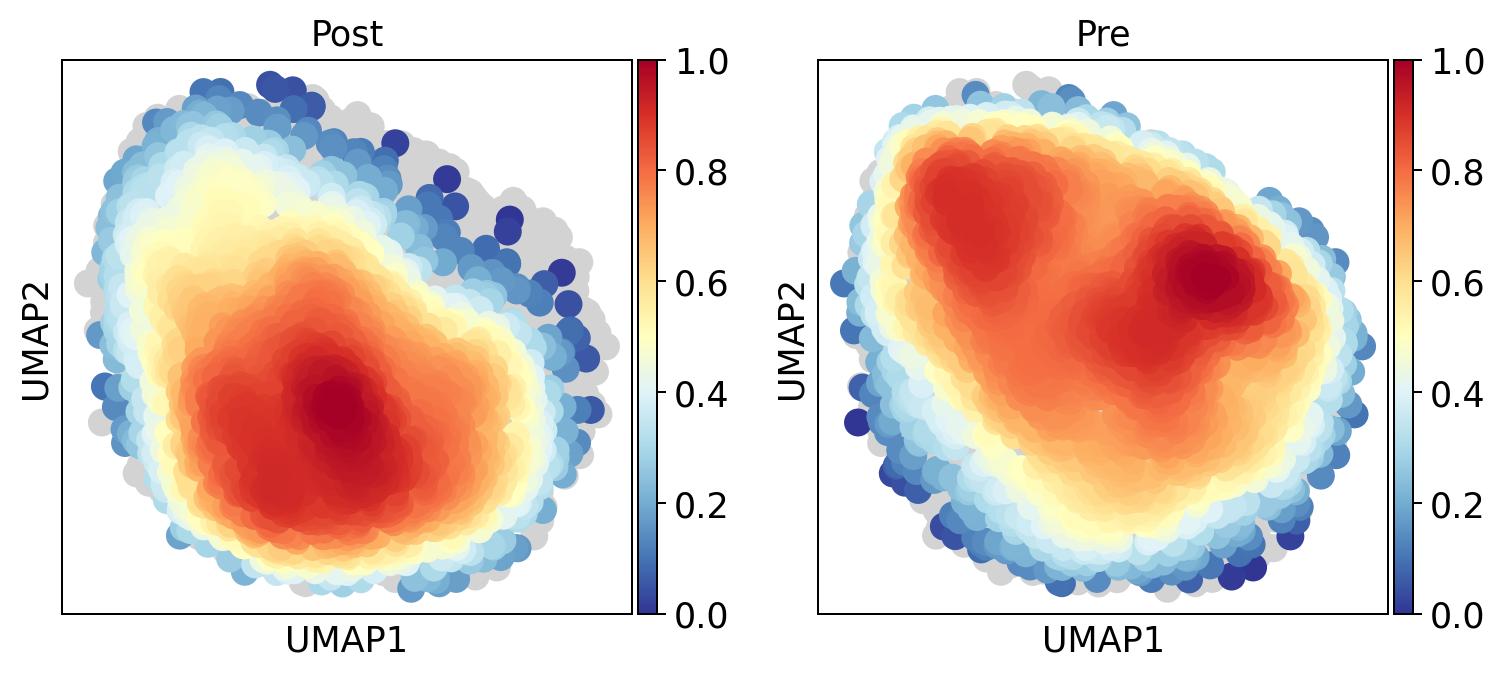

In [10]:
sc.set_figure_params(dpi=90)
sc.tl.embedding_density(naiveB_harm, basis='umap', groupby='Group', key_added='Group_density')
sc.pl.embedding_density(
    naiveB_harm, basis='umap', key="Group_density", ncols=2, color_map='RdYlBu_r',s=500
)

In [11]:
naiveB_gsea = pd.read_csv('/projects/USERS/yerrar/Lifestyle2024/scLifestyle_PREvPOST/Final_Files/GSEA_Results_v2/GSEA_DE_Naive_B.csv')
naiveB_gsea = naiveB_gsea.sort_values(by="NES", ascending=True)

target_pathway = "NaiveB"
leadedge_str = naiveB_gsea.loc[naiveB_gsea["pathway"] == target_pathway, "leadingEdge"].iat[0]
NaiveB_sig = leadedge_str.split(",")
len(NaiveB_sig)

15

In [12]:
naiveB_harm = naiveB_harm.raw.to_adata()
compute_pathway_score(naiveB_harm, NaiveB_sig, "NaiveB_sig")

adata = naiveB_harm.copy()
score = np.asarray(adata.obs['NaiveB_sig Pathway score']).reshape(-1, 1)

score_adata = AnnData(
    X=score,
    obs=adata.obs.copy(),
    var=pd.DataFrame(index=["NaiveB_sig Score"])
)
score_adata.obsm['X_umap'] = adata.obsm['X_umap']
score_adata.raw = score_adata

Computed NaiveB_sig Pathway Score using 15 genes.
['STX7', 'MEF2C', 'FCRL1', 'IL4R', 'TCL1A', 'CALHM6', 'CCND3', 'HVCN1', 'SELL', 'ADK', 'SLC25A45', 'LINC02397', 'TSPAN13', 'LINC00926', 'PLEKHF2']


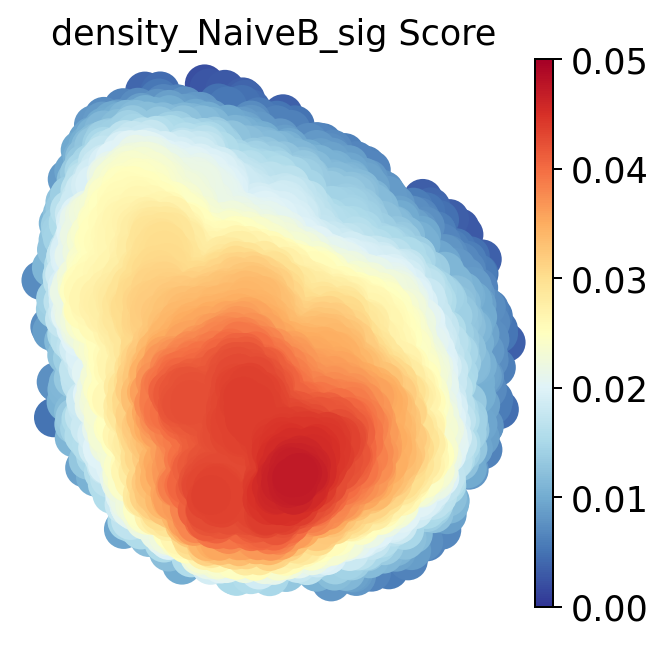

In [13]:
add_genes_density_to_obs_wkde(score_adata, genes=["NaiveB_sig Score"])
sc.settings.set_figure_params(dpi=90)
sc.pl.umap(
    score_adata,
    color=['density_NaiveB_sig Score'],
    size=1000,
    ncols=5,
    legend_fontsize=8,
    frameon=False,
    cmap='RdYlBu_r',
    vmin=0.00,
    vmax=0.05,
)

## Figure 5f

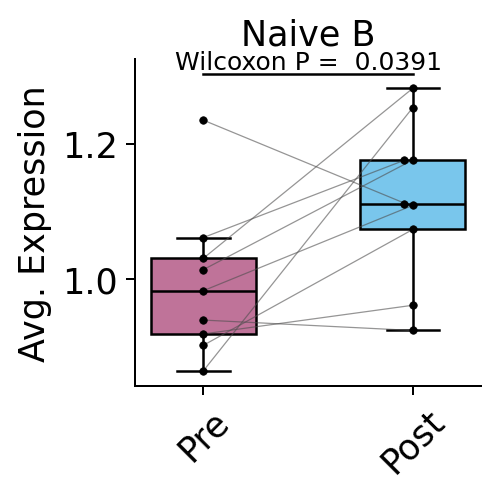

In [14]:
sc.set_figure_params(dpi=90)
pairs = getPairs()
curfig = plotExpression(
    adata=score_adata,
    pairs=pairs,
    genes=['NaiveB_sig Score'],
    title='Naive B',
    figsize=(3, 3)
)


## Figure 5g

In [15]:
lifespan = sc.read('/projects/USERS/dnehar/jupyter/lifespan/gex_data/old_data/h5ad/LS95_pbmc_10272025.h5ad')
lifespan

AnnData object with n_obs × n_vars = 581724 × 1153
    obs: 'Cells', 'IDs', 'Samples_ids', 'Names', 'Groups', 'runs_10x', 'Chemistry_10x', 'Age_months', 'n_genes', 'percent_mito', 'n_counts', 'annotated_clusters', 'SCs', 'Gender', 'Ethnicity', 'Annotations', 'umap_density_Groups', 'ReCluster', 'Lineage_v2', 'Ethnicity_v2', 'Age_months_v2', 'Sex', 'Simple_Clustering', 'Final_annotations2', 'Lineage', 'pbmc_simple_clustering', 'subset_simple_clustering', 'Final_annotations', 'CMVerify_prediction', 'CMVerify_probability'
    var: 'gene_ids', 'feature_types', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotations_colors', 'CMVerify_prediction_colors', 'Chemistry_10x_colors', 'Final_annotations2_colors', 'Final_annotations_colors', 'Groups_colors', 'LSCs_colors', 'Lineage_colors', 'Res1_2_BC_colors', 'Res1_2_Harm_colors', 'SOX4+ID3+_colors', 'SOX4+IKZF1+_colors', 'Simple_Clustering_colors', 'annotated_clusters_colors', 'dendrogram_Final

In [16]:
mycells = lifespan.obs.loc[lifespan.obs['Final_annotations'].isin(['B_naive'])].index
naiveB_LS = lifespan[mycells]
naiveB_LS_raw = naiveB_LS.raw.to_adata()

sig = [g for g in NaiveB_sig if g in naiveB_LS_raw.var_names]
missing = set(NaiveB_sig) - set(sig)
if missing:
    print(f"{len(missing)} genes not found", missing)

adata_sig = naiveB_LS_raw[:, sig].copy()
sc.pp.combat(adata_sig, key='Chemistry_10x')

compute_pathway_score(adata_sig, NaiveB_sig, "naiveness")

mycells = adata_sig.obs.loc[adata_sig.obs['Groups'].isin(['HO', 'HY'])].index
adata_sig = adata_sig[mycells]

Standardizing Data across genes.

Found 2 batches

Found 0 numerical variables:
	

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting data

Computed naiveness Pathway Score using 15 genes.
['STX7', 'MEF2C', 'FCRL1', 'IL4R', 'TCL1A', 'CALHM6', 'CCND3', 'HVCN1', 'SELL', 'ADK', 'SLC25A45', 'LINC02397', 'TSPAN13', 'LINC00926', 'PLEKHF2']


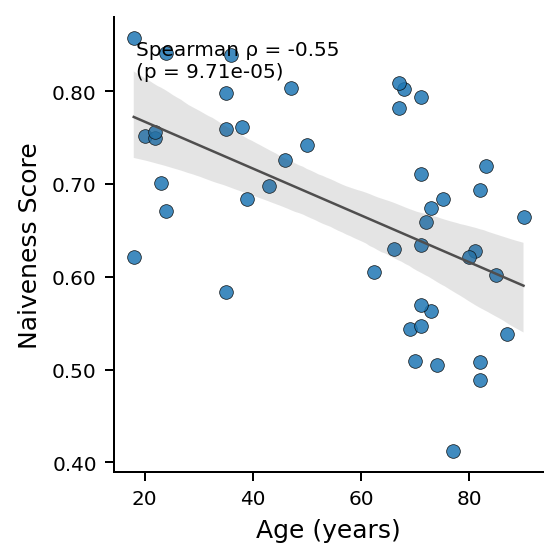

In [17]:
df = (
    adata_sig.obs
    .groupby('Samples_ids', as_index=False)
    .agg({
        'Age_months_v2': 'first',
        'naiveness Pathway score': 'mean',
        'Chemistry_10x': 'first'
    })
)

df['age'] = pd.to_numeric(df['Age_months_v2'].astype(str), errors='coerce')
df['score'] = pd.to_numeric(df['naiveness Pathway score'], errors='coerce')
df = df.dropna(subset=['age', 'score'])

x = df['age'] / 12
y = df['score']

spear_r, spear_p = stats.spearmanr(x, y)

fig, ax = plt.subplots(figsize=(3, 3), constrained_layout=True)

palette = sb.color_palette("Set2", len(df['Chemistry_10x'].unique()))
sb.scatterplot(x=x, y=y, palette=palette, s=30, edgecolor="black",
               linewidth=0.3, alpha=0.85, ax=ax)
sb.regplot(x=x, y=y, scatter=False, ax=ax, color="#4f4e4e", line_kws={"lw": 1})

ax.set_xlabel("Age (years)", fontsize=10)
ax.set_ylabel("Naiveness Score", fontsize=10)
ax.tick_params(axis="both", labelsize=8)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.2f"))
sb.despine(ax=ax, trim=False)
ax.grid(False)
ax.text(0.05, 0.95, f"Spearman \u03c1 = {spear_r:.2f}\n(p = {spear_p:.3g})",
        transform=ax.transAxes, ha="left", va="top", fontsize=8)

plt.show()